# 시즌별 판매 분석
- 시즌별 판매 추세 파악: 각 제품군별로 겨울, 봄, 여름, 가을 시즌에 따른 판매액의 변화를 파악
- 제품군별 성과 비교: 제품군별로 시즌에 따른 판매 성과를 비교함으로써, 어떤 제품군이 특정 시즌에 더 잘 팔리는지 파악


In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# MySQL 데이터베이스 연결 설정
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='doruru0614!@#',  # 실제 비밀번호로 변경하세요
    database='classicmodels'
)

In [5]:
# 각 productLine 별 시즌별 판매 추세 분석 쿼리
# 각 제품 라인(productLine)의 연도별(orderYear) 및 계절별(season) 총 매출(total_sales)을 계산하는 쿼리
# 어떤 계절에 어떤 제품 라인이 가장 많이 팔리는지 분석하는 것이 목적
query = """
SELECT
    p.productLine,  
    YEAR(o.orderDate) AS orderYear,                 -- 주문 연도 (YYYY 형식)

    -- 주문 월을 기준으로 계절을 분류
    CASE
        WHEN MONTH(o.orderDate) IN (12, 1, 2) THEN 'Winter' -- 12, 1, 2월 → 겨울
        WHEN MONTH(o.orderDate) IN (3, 4, 5) THEN 'Spring'  -- 3, 4, 5월 → 봄
        WHEN MONTH(o.orderDate) IN (6, 7, 8) THEN 'Summer'  -- 6, 7, 8월 → 여름
        ELSE 'Fall'                                         -- 나머지(9, 10, 11월) → 가을
    END AS season,

    -- 총 매출 계산 (판매 수량 × 개별 가격)
    SUM(od.quantityOrdered * od.priceEach) AS total_sales

FROM
    orders o 
JOIN
    orderdetails od ON o.orderNumber = od.orderNumber  
JOIN
    products p ON od.productCode = p.productCode  

GROUP BY
    p.productLine, orderYear, season  -- 제품 라인, 연도, 계절별로 그룹화

ORDER BY
    p.productLine, orderYear, season;  -- 제품 라인, 연도, 계절 순으로 정렬
"""

In [6]:
# SQL 쿼리 실행 및 결과 DataFrame으로 변환
df = pd.read_sql_query(query, conn)
df

,productLine,orderYear,season,total_sales
0,Classic Cars,2003,Fall,748931.95
1,Classic Cars,2003,Spring,247539.34
2,Classic Cars,2003,Summer,189163.28
3,Classic Cars,2003,Winter,189197.65
4,Classic Cars,2004,Fall,692945.95
...,...,...,...,...
65,Vintage Cars,2004,Spring,129595.00
66,Vintage Cars,2004,Summer,203715.28
67,Vintage Cars,2004,Winter,167479.44
68,Vintage Cars,2005,Spring,202025.19


In [7]:
# 연결 종료
conn.close()

In [8]:
# 제품군과 시즌별로 데이터를 분리하여 시각화
product_lines = df['productLine'].unique()
seasons = ['Winter', 'Spring', 'Summer', 'Fall']

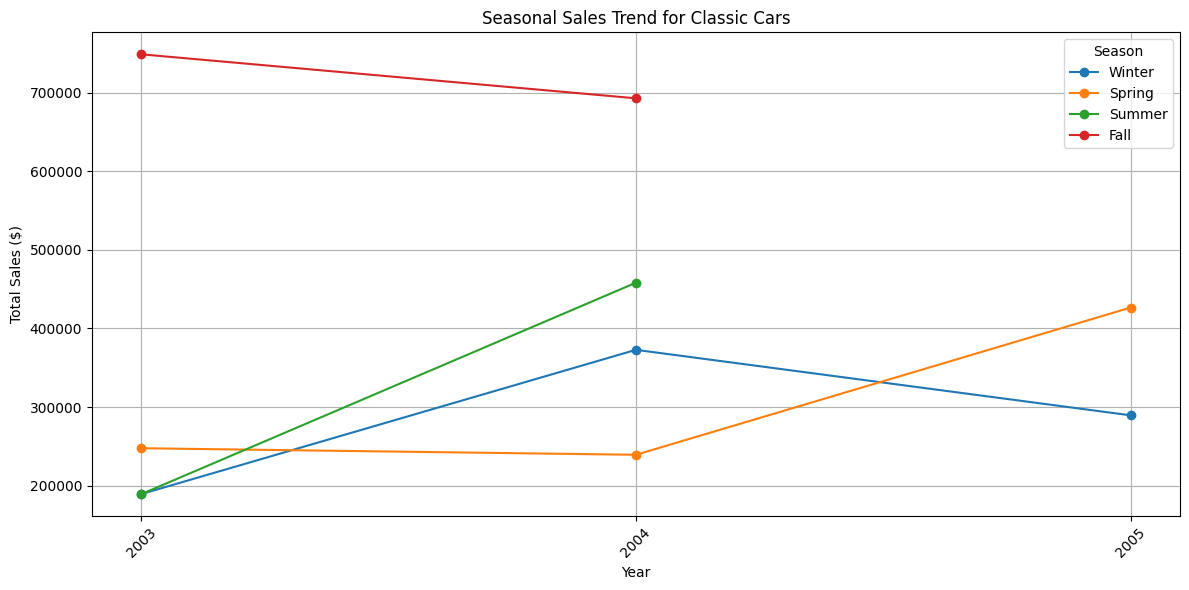

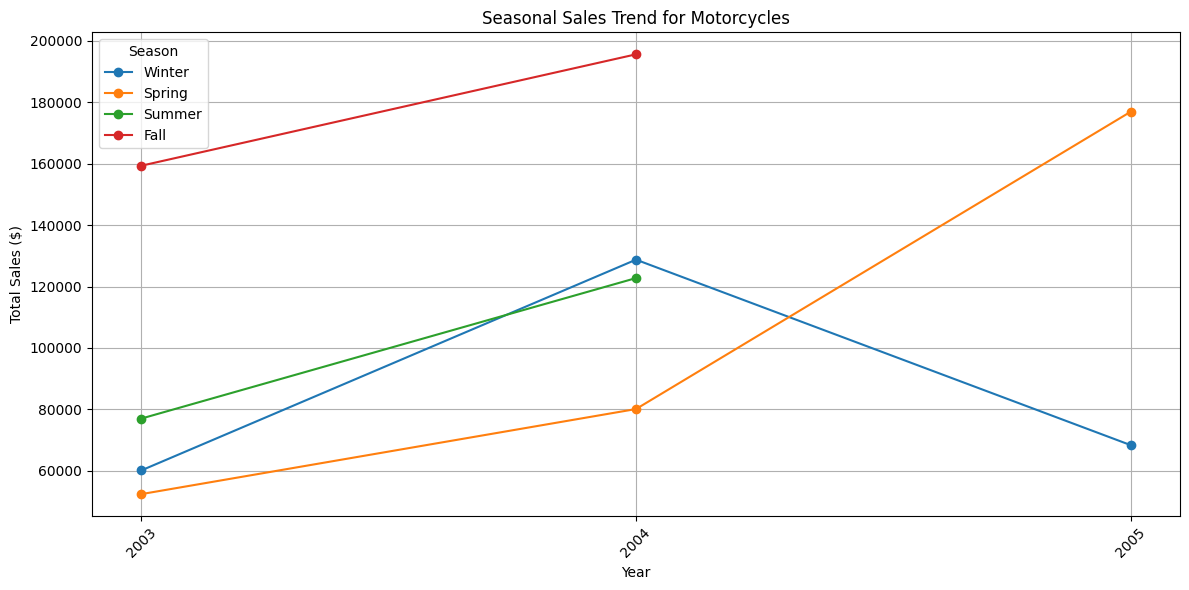

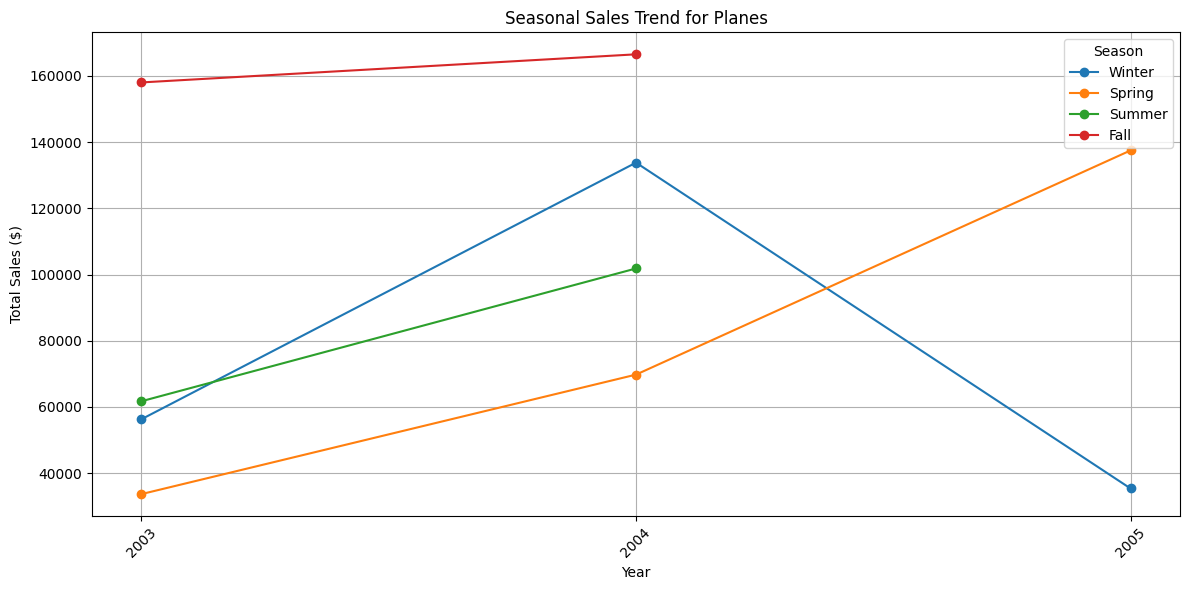

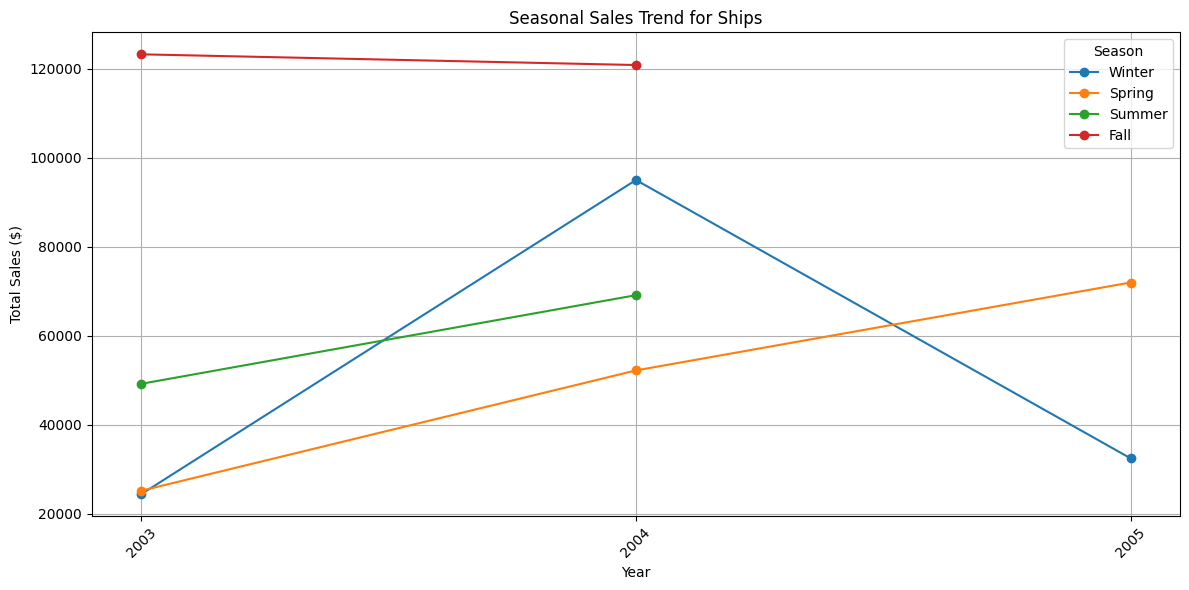

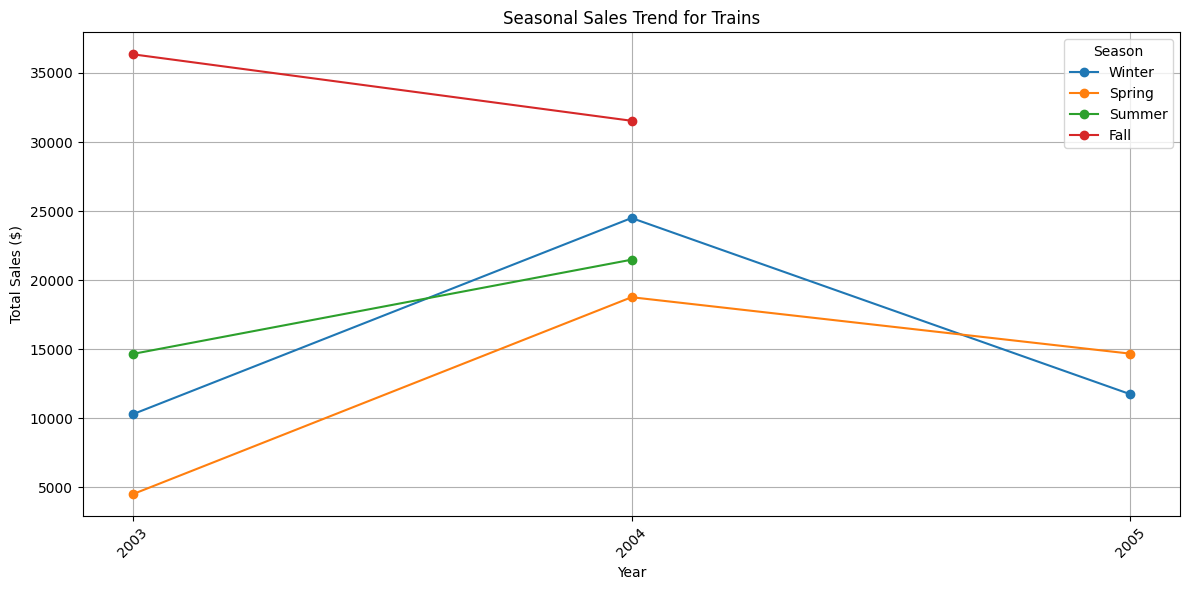

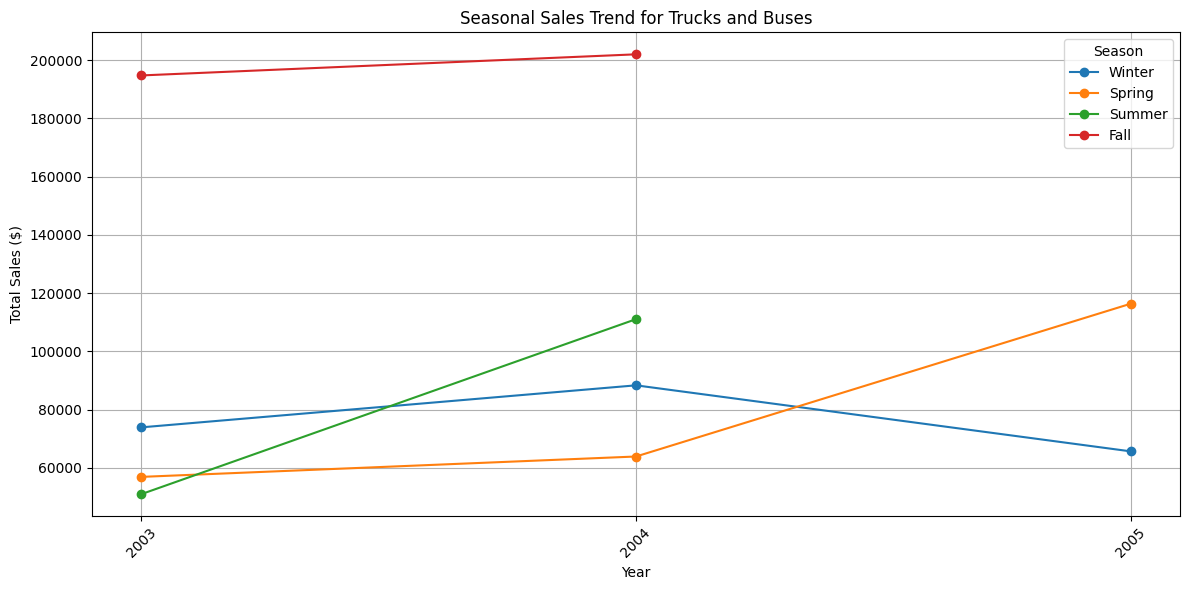

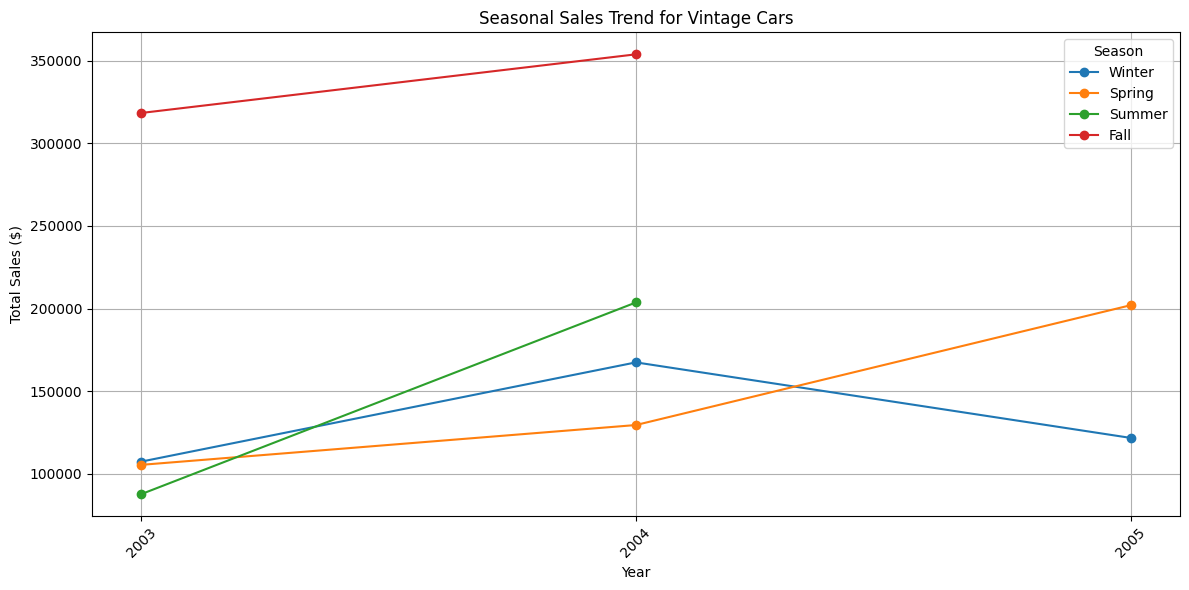

In [9]:
for product_line in product_lines:
    plt.figure(figsize=(12, 6))
    for season in seasons:
        subset = df[(df['productLine'] == product_line) & (df['season'] == season)]
        if not subset.empty:
            plt.plot(subset['orderYear'].astype(str), subset['total_sales'], marker='o', linestyle='-', label=season)

    plt.title(f'Seasonal Sales Trend for {product_line}')
    plt.xlabel('Year')
    plt.ylabel('Total Sales ($)')
    plt.legend(title='Season')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 회사 입장에서 취할수 있는 행동
- 시즌별 마케팅 전략 조정: 분석 결과를 통해 특정 시즌에 판매가 증가하는 제품군을 확인한 경우, 해당 시즌에 맞춰 마케팅 활동을 강화하여 판매를 더욱 촉진할 수 있음
- 재고 관리 최적화: 시즌별 판매 추세를 이해함으로써, 재고 수준을 조절하여 과잉 재고 또는 재고 부족 상황을 방지할 수 있음.
- 신제품 개발 및 기존 제품 개선: 일부 제품군이 특정 시즌에 성과가 저조한 경우, 제품 개선이나 신제품 개발을 통해 시장 수요를 더 잘 충족시킬 수 있도록 조치를 취할 수 있음.
- 시장 기회 식별: 분석을 통해 아직 충분히 활용되지 않은 시즌별 판매 기회를 식별할 수 있음
- 경쟁 우위 확보: 시즌별 판매 데이터를 분석함으로써, 경쟁사 대비 우리 회사의 제품군이 가지는 경쟁 우위를 파악하고 이를 기반으로 시장에서의 입지를 강화할 수 있음.

